In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv('/content/amazon_sales_data 2025.csv')
df

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending
...,...,...,...,...,...,...,...,...,...,...,...
245,ORD0246,17-03-25,T-Shirt,Clothing,20,2,40,Daniel Harris,Miami,Debit Card,Cancelled
246,ORD0247,30-03-25,Jeans,Clothing,40,1,40,Sophia Miller,Dallas,Debit Card,Cancelled
247,ORD0248,05-03-25,T-Shirt,Clothing,20,2,40,Chris White,Denver,Debit Card,Cancelled
248,ORD0249,08-03-25,Smartwatch,Electronics,150,3,450,Emily Johnson,New York,Debit Card,Cancelled


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB


In [11]:
df.describe()

,Price,Quantity,Total Sales
count,250.000000,250.000000,250.000000
mean,343.580000,2.856000,975.380000
std,380.635808,1.429489,1252.112254
min,15.000000,1.000000,15.000000
25%,40.000000,2.000000,100.000000
50%,150.000000,3.000000,400.000000
75%,600.000000,4.000000,1500.000000
max,1200.000000,5.000000,6000.000000


In [12]:
df.isnull().sum()

,0
Order ID,0
Date,0
Product,0
Category,0
Price,0
Quantity,0
Total Sales,0
Customer Name,0
Customer Location,0
Payment Method,0


In [16]:
##How many orders are there in the dataset?
df.shape[0]

250

In [19]:
##What are the top 3 most sold products (by quantity)?
df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(3)


,Quantity
Product,
Smartwatch,105
Smartphone,97
Laptop,73


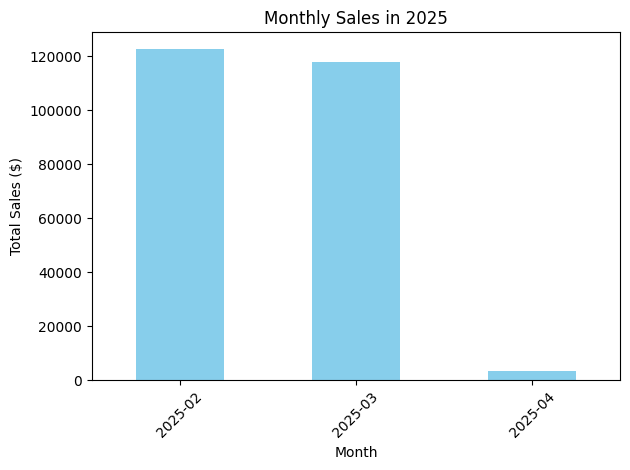

In [21]:
##Plot total monthly sales.
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%y')

# Group by month and sum 'Total Sales'
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Sales'].sum()

# Plotting
import matplotlib.pyplot as plt
monthly_sales.plot(kind='bar', title='Monthly Sales in 2025', color='skyblue')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
##Predict if an order will be Cancelled or not. Use only numerical and encoded categorical features.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Prepare data
df_ml = df.copy()
df_ml['Cancelled'] = df_ml['Status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

# Encode categorical columns
categorical_cols = ['Product', 'Category', 'Customer Location', 'Payment Method']
for col in categorical_cols:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

features = ['Price', 'Quantity', 'Total Sales'] + categorical_cols
X = df_ml[features]
y = df_ml['Cancelled']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy
accuracy_score(y_test, y_pred)

0.64

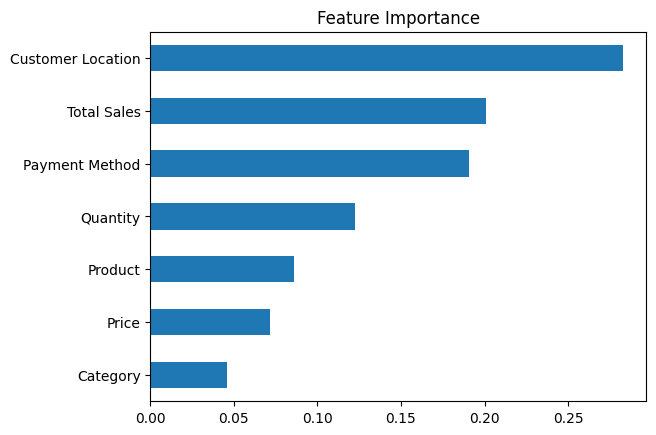

In [24]:
##What features are most important in predicting cancellations?
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=features)
feature_importances.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()


In [25]:
##Which payment method is most associated with cancellations?
df[df['Status'] == 'Cancelled']['Payment Method'].value_counts()


,count
Payment Method,
Debit Card,20
Gift Card,18
Credit Card,16
PayPal,16
Amazon Pay,7


In [26]:
## What customer location has the highest total sales?
df.groupby('Customer Location')['Total Sales'].sum().sort_values(ascending=False).head(1)

,Total Sales
Customer Location,
Miami,31700


In [27]:
##What is the average order value (AOV) across all orders?
df['Total Sales'].mean()

np.float64(975.38)

In [28]:
##Which weekday has the highest number of orders?
df['Weekday'] = df['Date'].dt.day_name()
df['Weekday'].value_counts()

,count
Weekday,
Monday,42
Sunday,40
Wednesday,37
Thursday,36
Friday,34
Tuesday,33
Saturday,28


In [29]:
##Which product category has the highest return/cancellation rate?
cancel_rate = df[df['Status'] == 'Cancelled'].groupby('Category').size() / df.groupby('Category').size()
cancel_rate.sort_values(ascending=False)

,0
Category,
Home Appliances,0.400000
Clothing,0.325000
Footwear,0.296296
Books,0.280000
Electronics,0.279661


In [31]:
##Perform customer segmentation by total sales and identify the top 5 high-value customers.
df.groupby('Customer Name')['Total Sales'].sum().sort_values(ascending=False).head(5)

,Total Sales
Customer Name,
Olivia Wilson,36170
Jane Smith,31185
Emma Clark,29700
John Doe,26870
Emily Johnson,23475
